In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, confusion_matrix,
                               roc_curve, ConfusionMatrixDisplay)

In [2]:
df = pd.read_csv('telecom_ibm_feature_engineered.csv')
print(df.shape)
df.head()

(7043, 43)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup,CustomerSegment
0,7590-VHVEG,Female,0,Yes,No,1,No,Yes,29.85,29.85,...,False,False,False,False,False,False,True,False,0-1 Yıl,Düşük Değerli Yeni Müşteri
1,5575-GNVDE,Male,0,No,No,34,Yes,No,56.95,1889.50,...,False,False,False,True,False,False,False,True,2-4 Yıl,Düşük Değerli Sadık Müşteri
2,3668-QPYBK,Male,0,No,No,2,Yes,Yes,53.85,108.15,...,False,False,False,False,False,False,False,True,0-1 Yıl,Düşük Değerli Yeni Müşteri
3,7795-CFOCW,Male,0,No,No,45,No,No,42.30,1840.75,...,False,False,False,True,False,False,False,False,2-4 Yıl,Düşük Değerli Sadık Müşteri
4,9237-HQITU,Female,0,No,No,2,Yes,Yes,70.70,151.65,...,False,False,False,False,False,False,True,False,0-1 Yıl,Yüksek Değerli Yeni Müşteri


In [3]:
drop_cols = [
    'customerID', 'Name', 'Churn', 'Churn_Binary', 'TenureGroup', 'CustomerSegment',
    'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'
]
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['Churn_Binary']

# Kontrol: hiç metin kolon kalmamalı
text_cols_remaining = X.select_dtypes(include='object').columns.tolist()
print("Hâlâ metin olan kolonlar:", text_cols_remaining)
print("X boyutu:", X.shape)

Hâlâ metin olan kolonlar: []
X boyutu: (7043, 32)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)

Eğitim seti: (5634, 32)
Test seti: (1409, 32)


In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
log_model = LogisticRegression(max_iter=1000)

cv_scores_log = cross_val_score(log_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("Logistic Regression - CV Ortalama Accuracy:", cv_scores_log.mean().round(4))

log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

Logistic Regression - CV Ortalama Accuracy: 0.801


In [7]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print("Random Forest - CV Ortalama Accuracy:", cv_scores_rf.mean().round(4))

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

Random Forest - CV Ortalama Accuracy: 0.7946


In [8]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='accuracy')
print("XGBoost - CV Ortalama Accuracy:", cv_scores_xgb.mean().round(4))

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

XGBoost - CV Ortalama Accuracy: 0.7751


In [9]:
model_results = pd.DataFrame({
    'ModelName': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Algorithm': ['LogisticRegression', 'RandomForestClassifier', 'XGBClassifier'],
    'CV_Accuracy': [cv_scores_log.mean(), cv_scores_rf.mean(), cv_scores_xgb.mean()],
    'Accuracy': [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_xgb)],
    'Recall': [recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_xgb)],
    'F1Score': [f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_xgb)],
    'ROC_AUC': [roc_auc_score(y_test, y_proba_log), roc_auc_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba_xgb)],
    'TrainDate': pd.Timestamp.now().strftime('%Y-%m-%d')
})

model_results.to_csv('churn_model_performance.csv', index=False)
model_results

,ModelName,Algorithm,CV_Accuracy,Accuracy,Precision,Recall,F1Score,ROC_AUC,TrainDate
0,Logistic Regression,LogisticRegression,0.801029,0.819021,0.680982,0.595174,0.635193,0.861868,2026-07-10
1,Random Forest,RandomForestClassifier,0.794638,0.789212,0.638686,0.469169,0.540958,0.846002,2026-07-10
2,XGBoost,XGBClassifier,0.775111,0.794890,0.638158,0.520107,0.573117,0.840964,2026-07-10


In [10]:
test_customer_ids = df.loc[X_test.index, 'customerID']

churn_predictions = pd.DataFrame({
    'CustomerId': test_customer_ids,
    'ActualChurn': y_test.values,
    'PredictedChurn': y_pred_rf,
    'ChurnProbability': y_proba_rf.round(4)
})

churn_predictions.to_csv('churn_predictions.csv', index=False)
churn_predictions.head(10)

,CustomerId,ActualChurn,PredictedChurn,ChurnProbability
185,1024-GUALD,1,1,0.70
2715,0484-JPBRU,0,0,0.05
3825,3620-EHIMZ,0,0,0.01
1807,6910-HADCM,1,1,0.84
132,8587-XYZSF,0,0,0.05
1263,6818-WOBHJ,1,0,0.15
3732,3082-YVEKW,0,0,0.08
1672,4737-AQCPU,0,0,0.03
811,4853-RULSV,1,0,0.15
2526,5766-ZJYBB,1,0,0.28


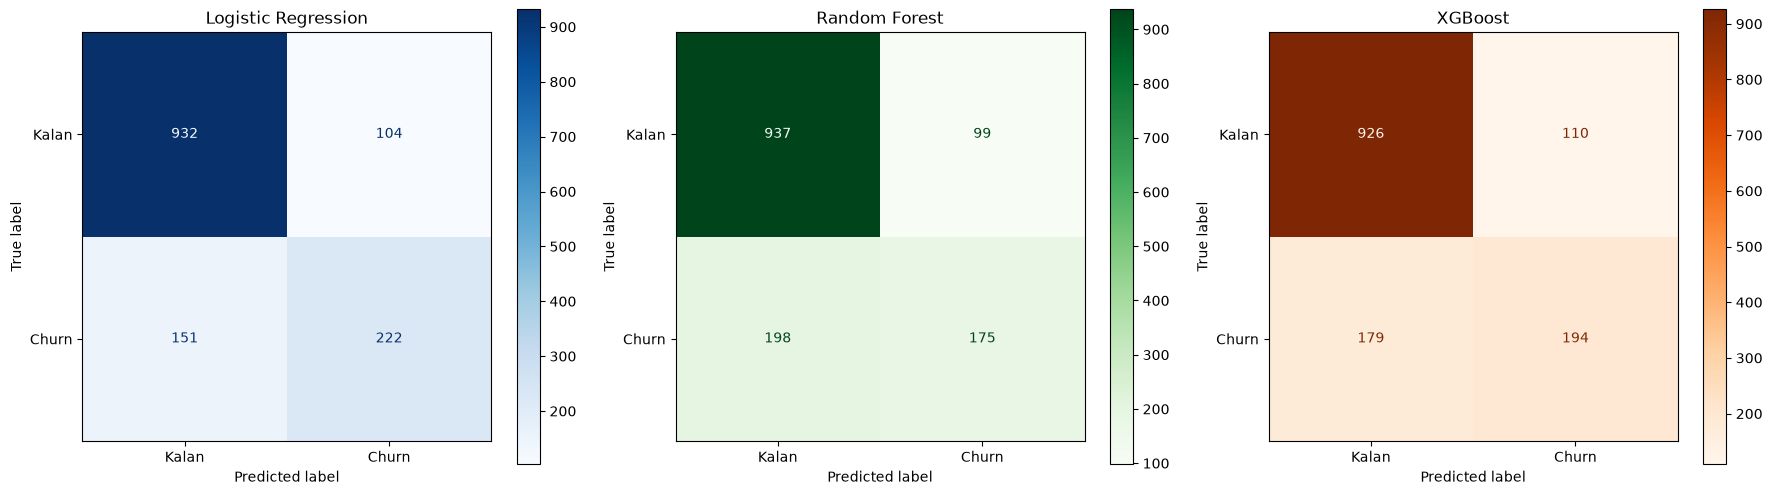

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log, display_labels=['Kalan', 'Churn']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Kalan', 'Churn']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=['Kalan', 'Churn']).plot(ax=axes[2], cmap='Oranges')
axes[2].set_title('XGBoost')

plt.tight_layout()
plt.savefig('churn_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

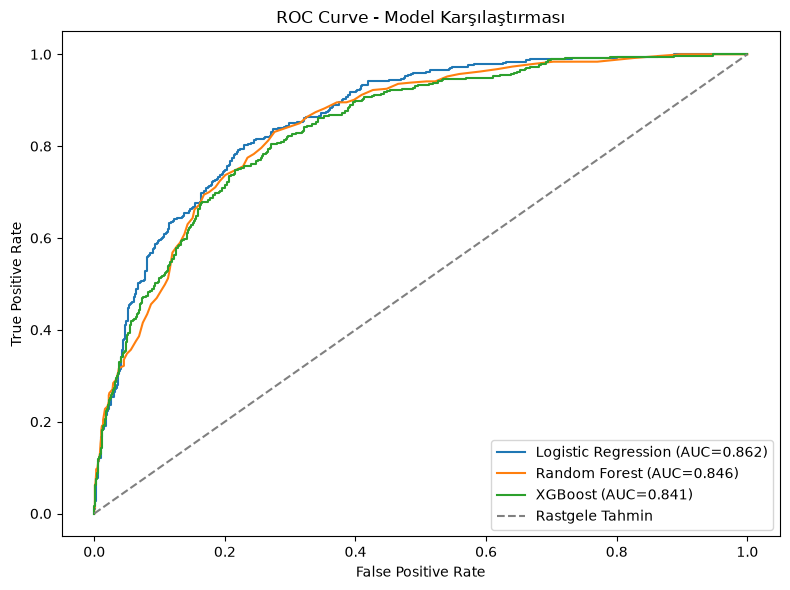

In [12]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_proba_log):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_test, y_proba_xgb):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Rastgele Tahmin')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Karşılaştırması')
plt.legend()
plt.tight_layout()
plt.savefig('churn_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

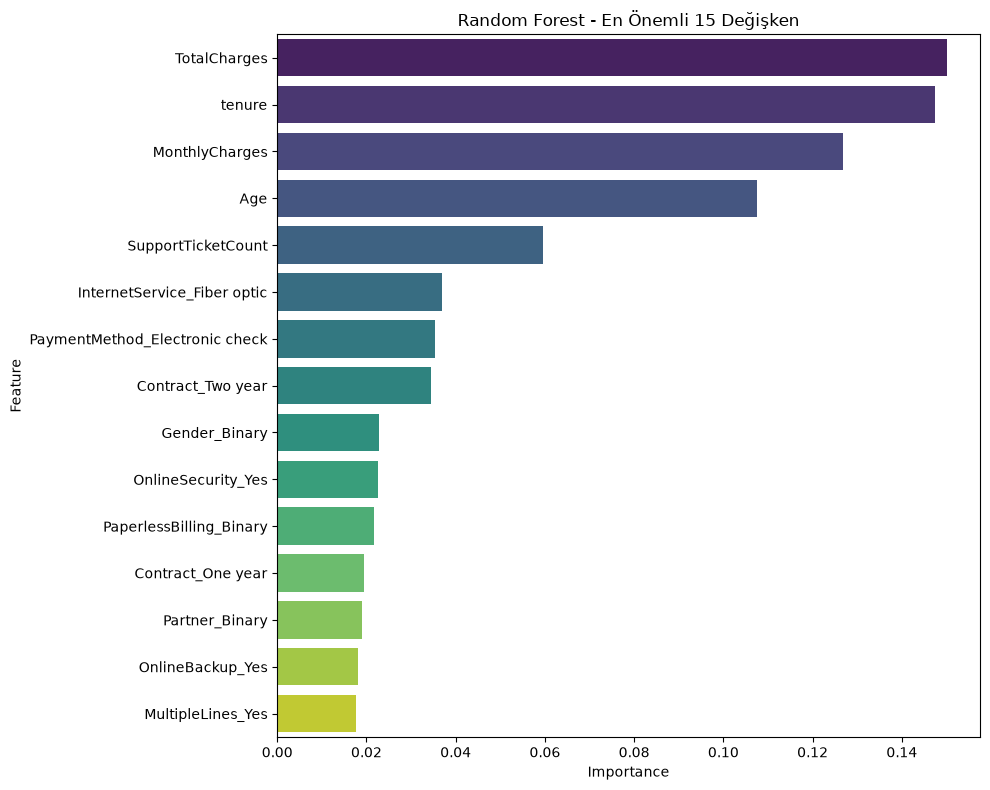

In [13]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances, y='Feature', x='Importance', hue='Feature', palette='viridis', legend=False)
plt.title('Random Forest - En Önemli 15 Değişken')
plt.tight_layout()
plt.savefig('churn_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

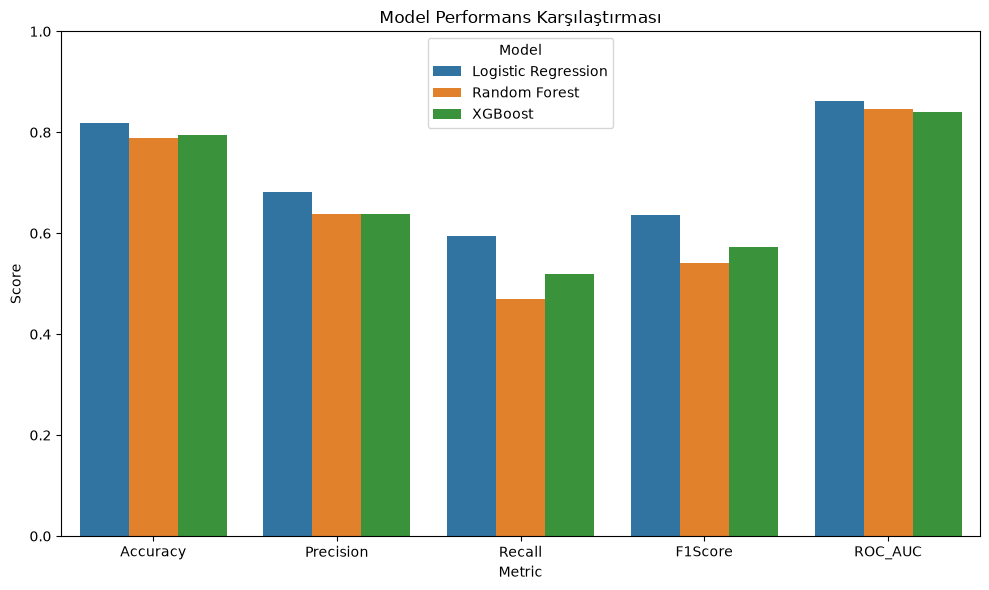

In [14]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1Score', 'ROC_AUC']
plot_data = model_results.melt(id_vars='ModelName', value_vars=metrics_to_plot,
                                  var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='Metric', y='Score', hue='ModelName')
plt.title('Model Performans Karşılaştırması')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.tight_layout()
plt.savefig('churn_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
import joblib

joblib.dump(log_model, 'churn_model_logistic_regression.pkl')

joblib.dump(rf_model, 'churn_model_random_forest.pkl')

joblib.dump(xgb_model, 'churn_model_xgboost.pkl')

joblib.dump(scaler, 'churn_scaler.pkl')

print("Churn modelleri kaydedildi.")

Churn modelleri kaydedildi.
